# Used-Car Price Prediction

This notebook trains and evaluates regression models that estimate a used vehicle's listed price from its age, mileage, technical specifications, brand, location, fuel type, transmission, and ownership history.

## Modelling approach

- Target: `price`, measured in lakh
- Train/test split: 80/20 with `random_state=42`
- Numeric missing values: median imputation fitted on training data only
- Categorical missing values: most-frequent-value imputation fitted on training data only
- Categorical encoding: one-hot encoding
- Models: median baseline, Ridge Regression, and Random Forest Regressor
- Evaluation metrics: MAE, RMSE, and \(R^2\)
- Additional experiment: models trained using `log1p(price)`, evaluated after converting predictions back to lakh

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

In [5]:
DATA_PATH = Path(r"..\data\processed form\used_cars_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

Dataset shape: (6019, 14)


,name,brand,location,year,vehicle_age,kilometers_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,power_bhp,seats,price
0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,10,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,5,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Honda,Chennai,2011,9,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Maruti,Chennai,2012,8,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,7,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74



Missing values:


power_bhp            143
mileage_kmpl          70
seats                 43
engine_cc             37
kilometers_driven      4
name                   0
vehicle_age            0
year                   0
location               0
brand                  0
owner_type             0
transmission           0
fuel_type              0
price                  0
dtype: int64

## Feature selection

The raw vehicle `name` is excluded from the initial model because it is a high-cardinality string field. The extracted `brand` feature retains manufacturer information while avoiding thousands of sparse model-name categories.

`year` is excluded because `vehicle_age` contains the same temporal information in a more directly interpretable form.

In [10]:
target = "price"
numeric_features = ["vehicle_age","kilometers_driven","mileage_kmpl","engine_cc","power_bhp","seats",]
categorical_features = ["brand","location","fuel_type","transmission","owner_type",]

features = numeric_features+categorical_features

X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (6019, 11)
Target shape: (6019,)


,vehicle_age,kilometers_driven,mileage_kmpl,engine_cc,power_bhp,seats,brand,location,fuel_type,transmission,owner_type
0,10,72000.0,26.60,998.0,58.16,5.0,Maruti,Mumbai,CNG,Manual,First
1,5,41000.0,19.67,1582.0,126.20,5.0,Hyundai,Pune,Diesel,Manual,First
2,9,46000.0,18.20,1199.0,88.70,5.0,Honda,Chennai,Petrol,Manual,First
3,8,87000.0,20.77,1248.0,88.76,7.0,Maruti,Chennai,Diesel,Manual,First
4,7,40670.0,15.20,1968.0,140.80,5.0,Audi,Coimbatore,Diesel,Automatic,Second


In [11]:
assert y.isna().sum() == 0, "Target contains missing values."
assert (y > 0).all(), "Target contains zero or negative values."

print("Target checks passed.")

Target checks passed.


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Training shape: (4815, 11)
Test shape: (1204, 11)
Training target shape: (4815,)
Test target shape: (1204,)


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Test targets:", y_test.shape)

Training features: (4815, 11)
Test features: (1204, 11)
Training targets: (4815,)
Test targets: (1204,)


In [14]:
split_summary = pd.DataFrame({"train": y_train.describe(),"test": y_test.describe(),})

split_summary

,train,test
count,4815.000000,1204.000000
mean,9.508147,9.364776
std,11.211293,11.097828
min,0.440000,0.450000
25%,3.500000,3.450000
50%,5.660000,5.500000
75%,9.990000,9.800000
max,160.000000,97.070000


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Preprocessing

Numeric features are median-imputed and standardised. Categorical features are imputed using the most common value and one-hot encoded.

All transformations are included inside a scikit-learn pipeline so they are fitted exclusively on the training split and then applied consistently to unseen data.

In [18]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features),
    ],
    remainder="drop",
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (4815, 57)
Processed test shape: (1204, 57)


In [20]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))
print("\nFirst 25 processed features:")
print(processed_feature_names[:25])

Number of processed features: 57

First 25 processed features:
['numeric__vehicle_age' 'numeric__kilometers_driven'
 'numeric__mileage_kmpl' 'numeric__engine_cc' 'numeric__power_bhp'
 'numeric__seats' 'categorical__brand_Audi' 'categorical__brand_BMW'
 'categorical__brand_Bentley' 'categorical__brand_Chevrolet'
 'categorical__brand_Datsun' 'categorical__brand_Fiat'
 'categorical__brand_Force' 'categorical__brand_Ford'
 'categorical__brand_Honda' 'categorical__brand_Hyundai'
 'categorical__brand_ISUZU' 'categorical__brand_Isuzu'
 'categorical__brand_Jaguar' 'categorical__brand_Jeep'
 'categorical__brand_Lamborghini' 'categorical__brand_Land'
 'categorical__brand_Mahindra' 'categorical__brand_Maruti'
 'categorical__brand_Mercedes-Benz']


In [21]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [22]:
assert y.isna().sum() == 0, "Target contains missing values."
assert (y > 0).all(), "Target contains zero or negative values."

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Test targets:", y_test.shape)

Training features: (4815, 11)
Test features: (1204, 11)
Training targets: (4815,)
Test targets: (1204,)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features),
    ],
    remainder="drop",
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [24]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

feature_names = preprocessor.get_feature_names_out()

print("\nNumber of processed features:", len(feature_names))
print("\nFirst 20 processed feature names:")
print(feature_names[:20])

Processed training shape: (4815, 57)
Processed test shape: (1204, 57)

Number of processed features: 57

First 20 processed feature names:
['numeric__vehicle_age' 'numeric__kilometers_driven'
 'numeric__mileage_kmpl' 'numeric__engine_cc' 'numeric__power_bhp'
 'numeric__seats' 'categorical__brand_Audi' 'categorical__brand_BMW'
 'categorical__brand_Bentley' 'categorical__brand_Chevrolet'
 'categorical__brand_Datsun' 'categorical__brand_Fiat'
 'categorical__brand_Force' 'categorical__brand_Ford'
 'categorical__brand_Honda' 'categorical__brand_Hyundai'
 'categorical__brand_ISUZU' 'categorical__brand_Isuzu'
 'categorical__brand_Jaguar' 'categorical__brand_Jeep']


In [25]:
from sklearn.metrics import ( mean_absolute_error,mean_squared_error,r2_score,)

def evaluate_regression_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }

In [26]:
from sklearn.dummy import DummyRegressor

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median")),
    ]
)

dummy_pipeline.fit(X_train, y_train)

dummy_predictions = dummy_pipeline.predict(X_test)

baseline_results = evaluate_regression_model(
    "Median baseline",
    y_test,
    dummy_predictions,
)

pd.DataFrame([baseline_results]).round(3)

,model,mae,rmse,r2
0,Median baseline,5.998,11.696,-0.112


## Baseline result

The median-price basline achieved an MAE of 5.998 lakh, RSME of 11.698 lakh and \(R^2\) of −0.112 on the test set. It predicts a single constant price for every vehicle and does not use any vehicle characteristics. These results establish the minimum benchmark that feature-based regression models must exceed.

In [29]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]
)

ridge_pipeline.fit(X_train, y_train)

ridge_predictions = ridge_pipeline.predict(X_test)

ridge_results = evaluate_regression_model(
    "Ridge Regression",
    y_test,
    ridge_predictions,
)

pd.DataFrame([ridge_results]).round(3)

,model,mae,rmse,r2
0,Ridge Regression,3.118,5.409,0.762


### Ridge Regression result

Ridge Regression majorly outdid the median-price baseline. On the held-out test set, it achieved an MAE of 3.118 lakh, RMSE of 5.409 lakh, and \(R^2\) of 0.762.

This indicates that a regularised linear combination of vehicle characteristics explains a substantial proportion of variation in listing prices. Ridge regularisation is useful here because several predictors may be correlated, particularly engine displacement and power.

In [30]:
from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_pipeline.fit(X_train, y_train)

random_forest_predictions = random_forest_pipeline.predict(X_test)

random_forest_results = evaluate_regression_model(
    "Random Forest",
    y_test,
    random_forest_predictions,
)

pd.DataFrame([random_forest_results]).round(3)

,model,mae,rmse,r2
0,Random Forest,1.784,3.917,0.875


### Random Forest result

Random Forest achievied the strongest performance among the raw-price models, with an MAE of 1.784 lakh, RMSE of 3.917 lakh, and \(R^2\) of 0.875.

Compared with Ridge Regression, Random Forest reduced MAE from 3.118 lakh to 1.784 lakh and increased \(R^2\) from 0.762 to 0.875. This suggests that non-linear relationships and interactions among vehicle characteristics—such as brand, age, power, mileage, and transmission—are important for predicting listed price.

In [31]:
raw_target_results = pd.DataFrame(
    [
        baseline_results,
        ridge_results,
        random_forest_results,
    ]
).sort_values("mae")

raw_target_results.round(3)

,model,mae,rmse,r2
2,Random Forest,1.784,3.917,0.875
1,Ridge Regression,3.118,5.409,0.762
0,Median baseline,5.998,11.696,-0.112


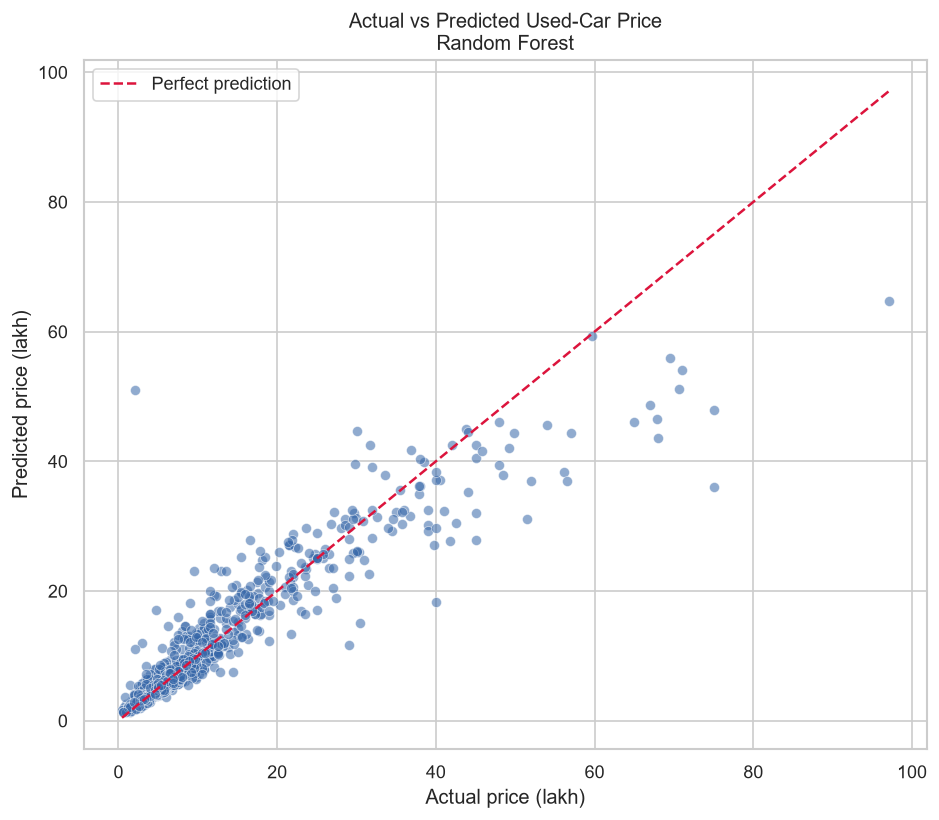

In [32]:
fig, ax = plt.subplots(figsize=(8, 7))

sns.scatterplot(
    x=y_test,
    y=random_forest_predictions,
    alpha=0.55,
    color="#3566a8",
    ax=ax,
)

minimum = min(y_test.min(), random_forest_predictions.min())
maximum = max(y_test.max(), random_forest_predictions.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction",
)

ax.set_title("Actual vs Predicted Used-Car Price\nRandom Forest")
ax.set_xlabel("Actual price (lakh)")
ax.set_ylabel("Predicted price (lakh)")
ax.legend()

plt.tight_layout()
plt.show()

In [34]:
FIGURES_PATH = Path(r"..\outputs\figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURES_PATH / "random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)

In [35]:
prediction_errors = X_test.copy()
prediction_errors["actual_price"] = y_test
prediction_errors["predicted_price"] = random_forest_predictions
prediction_errors["absolute_error"] = (prediction_errors["actual_price"] - prediction_errors["predicted_price"]).abs()

prediction_errors = prediction_errors.sort_values("absolute_error", ascending=False)
display(prediction_errors.head(15))

,vehicle_age,kilometers_driven,mileage_kmpl,engine_cc,power_bhp,seats,brand,location,fuel_type,transmission,owner_type,actual_price,predicted_price,absolute_error
3132,1,14298.0,13.33,2995.0,340.00,5.0,Porsche,Kochi,Petrol,Automatic,First,2.02,51.028761,49.008761
655,3,10501.0,9.43,1999.0,237.40,5.0,Jaguar,Mumbai,Petrol,Automatic,First,75.00,36.104762,38.895238
1505,1,26013.0,12.65,2993.0,255.00,5.0,Land,Kochi,Diesel,Automatic,First,97.07,64.737182,32.332818
3489,7,19828.0,17.85,2967.0,300.00,4.0,Porsche,Bangalore,Diesel,Automatic,Second,75.00,47.864924,27.135076
5009,3,59500.0,14.75,2967.0,245.00,7.0,Audi,Pune,Diesel,Automatic,First,68.00,43.531200,24.468800
926,10,10000.0,9.00,3436.0,NaN,2.0,Porsche,Hyderabad,Petrol,Manual,First,40.00,18.359012,21.640988
5341,4,65003.0,13.60,4134.0,382.00,5.0,Porsche,Coimbatore,Diesel,Automatic,First,67.83,46.555914,21.274086
473,2,26405.0,12.60,1950.0,191.34,5.0,Mercedes-Benz,Kochi,Petrol,Automatic,First,51.43,31.153497,20.276503
2509,2,11000.0,16.10,1950.0,194.00,5.0,Mercedes-Benz,Mumbai,Diesel,Automatic,First,56.50,36.915579,19.584421
3752,5,38467.0,12.65,2993.0,255.00,5.0,Land,Kochi,Diesel,Automatic,First,70.66,51.114136,19.545864


In [36]:
y_train_log = np.log1p(y_train)

In [37]:
ridge_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]
)

ridge_log_pipeline.fit(X_train, y_train_log)

ridge_log_predictions = np.expm1(
    ridge_log_pipeline.predict(X_test)
)

ridge_log_results = evaluate_regression_model(
    "Ridge Regression (log target)",
    y_test,
    ridge_log_predictions,
)

pd.DataFrame([ridge_log_results]).round(3)

,model,mae,rmse,r2
0,Ridge Regression (log target),1.844,4.365,0.845


In [38]:
random_forest_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_log_pipeline.fit(X_train, y_train_log)

random_forest_log_predictions = np.expm1(
    random_forest_log_pipeline.predict(X_test)
)

random_forest_log_results = evaluate_regression_model(
    "Random Forest (log target)",
    y_test,
    random_forest_log_predictions,
)

pd.DataFrame([random_forest_log_results]).round(3)

,model,mae,rmse,r2
0,Random Forest (log target),1.772,4.329,0.848


In [39]:
all_results = pd.DataFrame(
    [
        baseline_results,
        ridge_results,
        random_forest_results,
        ridge_log_results,
        random_forest_log_results,
    ]
).sort_values("mae")

all_results.round(3)

,model,mae,rmse,r2
4,Random Forest (log target),1.772,4.329,0.848
2,Random Forest,1.784,3.917,0.875
3,Ridge Regression (log target),1.844,4.365,0.845
1,Ridge Regression,3.118,5.409,0.762
0,Median baseline,5.998,11.696,-0.112


In [40]:
RESULTS_PATH = Path("..\outputs\model_results.csv")
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

all_results.to_csv(RESULTS_PATH, index=False)

print("Saved results to:", RESULTS_PATH.resolve())

Saved results to: C:\Users\kenda\Documents\Projects\used-car-price-prediction\outputs\model_results.csv


<>:1: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:1: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\kenda\AppData\Local\Temp\ipykernel_30404\3850837000.py:1: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  RESULTS_PATH = Path("..\outputs\model_results.csv")


### Model selection

The raw-target Random Forest was selected as the primary model because it achieved the strongest overall fit on the original price scale, with an RMSE of 3.917 lakh and \(R^2\) of 0.875. Even though the log-target Random Forest achieved a marginally lower MAE (1.772 versus 1.784 lakh), its RMSE was higher (4.329 versus 3.917 lakh), indicating larger errors on some listings.

The log-target model is retained as a complementary model because it slightly improved typical absolute prediction error and may be preferable when relative error across lower- and mid-priced vehicles is prioritised.

### Brand-extraction limitation

Brand was extracted from the first word of each listing name. This simplifies many manufacturers correctly but creates imperfect labels for multi-word brands, such as `Land Rover` being represented as `Land`. Future work should use a validated manufacturer-mapping dictionary or extract make/model information more carefully.

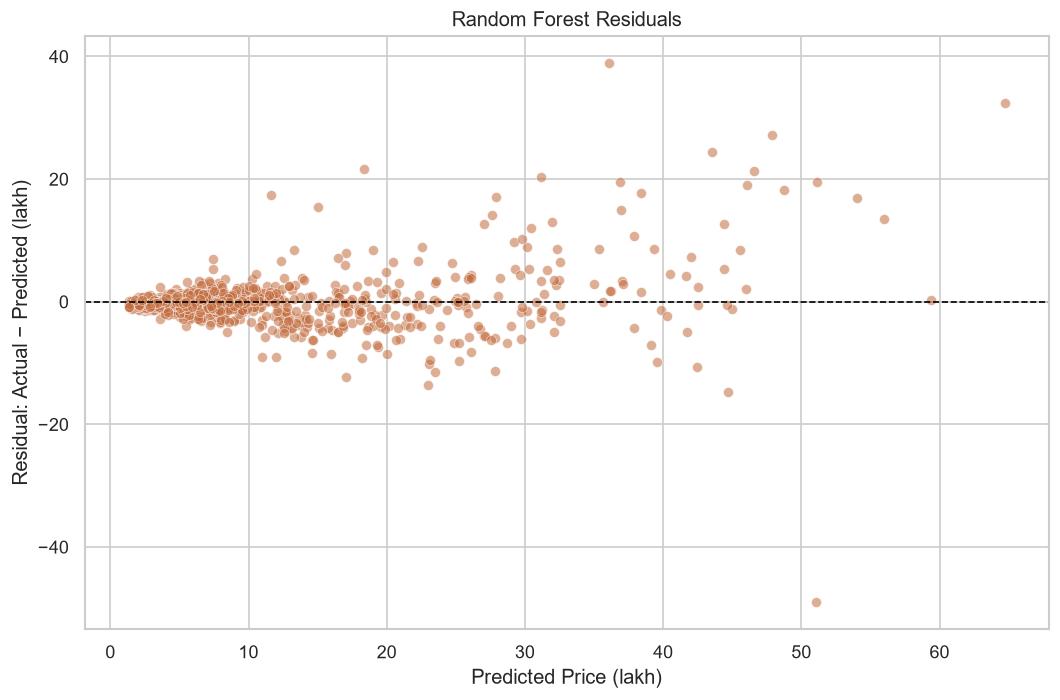

In [42]:
residuals = y_test - random_forest_predictions

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    x=random_forest_predictions,
    y=residuals,
    alpha=0.55,
    color="#c26b3c",
    ax=ax,
)

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title("Random Forest Residuals")
ax.set_xlabel("Predicted Price (lakh)")
ax.set_ylabel("Residual: Actual − Predicted (lakh)")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "random_forest_residuals.png",
    dpi=300,
    bbox_inches="tight",
)

In [43]:
fitted_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
fitted_model = random_forest_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": fitted_preprocessor.get_feature_names_out(),
    "importance": fitted_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
4,numeric__power_bhp,0.240010
3,numeric__engine_cc,0.156763
51,categorical__transmission_Automatic,0.090826
52,categorical__transmission_Manual,0.083481
0,numeric__vehicle_age,0.079307
1,numeric__kilometers_driven,0.062089
2,numeric__mileage_kmpl,0.053452
5,numeric__seats,0.030501
24,categorical__brand_Mercedes-Benz,0.028557
50,categorical__fuel_type_Petrol,0.023367


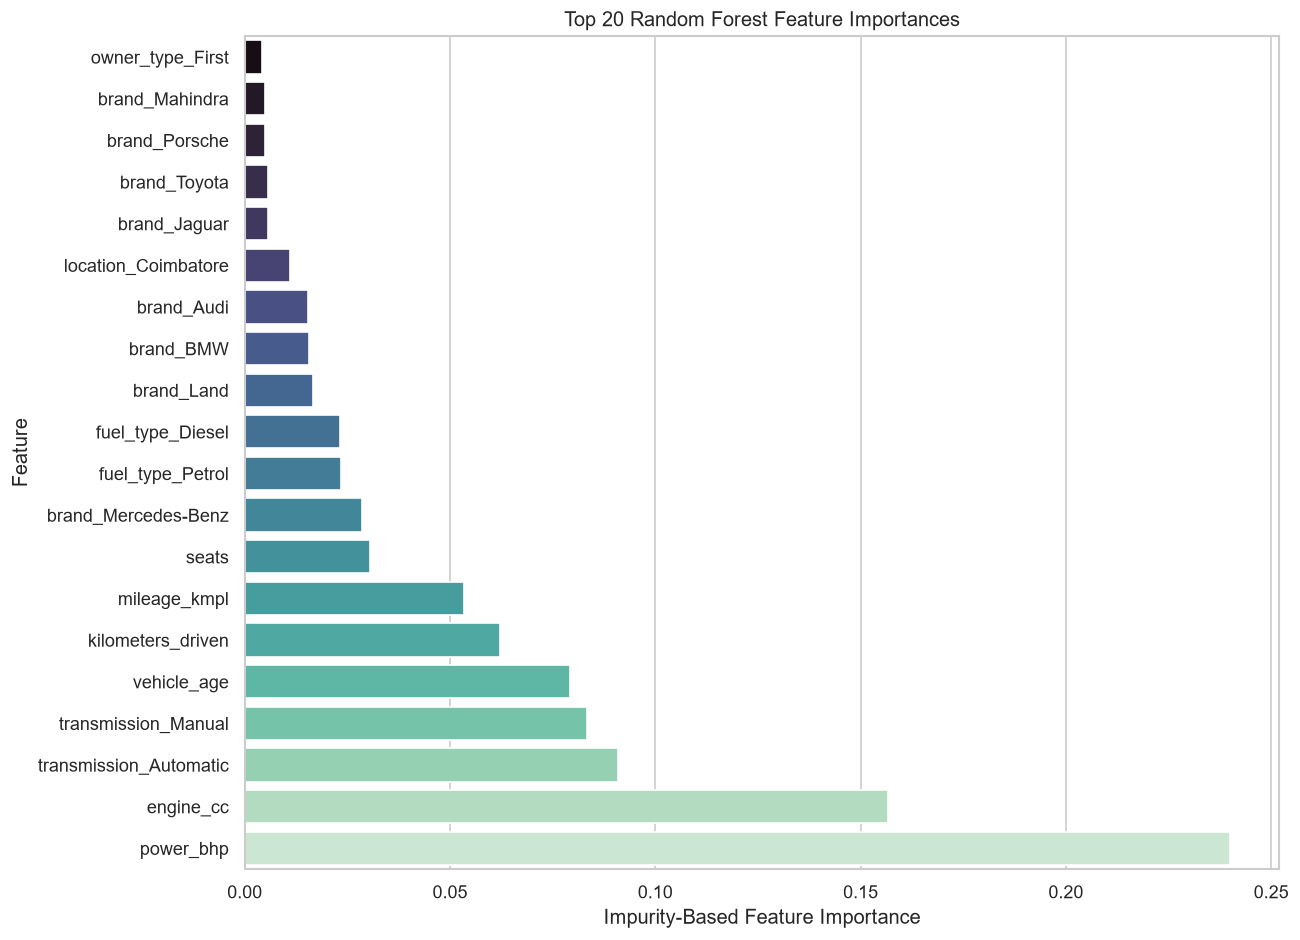

In [44]:
top_features = feature_importance.head(20).copy()

top_features["feature"] = (
    top_features["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=top_features.sort_values("importance"),
    x="importance",
    y="feature",
    hue="feature",
    legend=False,
    palette="mako",
    ax=ax,
)

ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Impurity-Based Feature Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

### Feature-importance interpretation

Impurity-based Random Forest feature importances indicate that `power_bhp` was the most influential individual predictor (0.240), followed by `engine_cc` (0.157). Vehicle transmission was also highly influential: the combined importance of the automatic and manual transmission indicators was approximately 0.174.

Vehicle age (0.079), kilometres driven (0.062), mileage (0.053), and seating capacity (0.031) contributed meaningful additional predictive information. Premium-brand indicators, including Mercedes-Benz, BMW, Audi, Land Rover—represented as `Land` due to the first-word brand-extraction rule—and Jaguar also contributed to the model.

These values show how frequently and how effectively the fitted Random Forest used variables to reduce prediction error across its decision trees. They are model-specific predictive associations, not causal effects, and correlated variables can share or redistribute importance.

In [45]:
def feature_group(feature_name):
    if feature_name.startswith("numeric__"):
        return feature_name.replace("numeric__", "")

    if feature_name.startswith("categorical__"):
        remaining = feature_name.replace("categorical__", "")

        for original_feature in categorical_features:
            prefix = f"{original_feature}_"

            if remaining.startswith(prefix):
                return original_feature

        return "other_categorical"

    return "other"


grouped_importance = (
    feature_importance.assign(
        feature_group=feature_importance["feature"].apply(feature_group)
    )
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

grouped_importance

,feature_group,importance
7,power_bhp,0.240010
9,transmission,0.174307
1,engine_cc,0.156763
0,brand,0.119175
10,vehicle_age,0.079307
3,kilometers_driven,0.062089
5,mileage_kmpl,0.053452
2,fuel_type,0.046564
8,seats,0.030501
4,location,0.029572


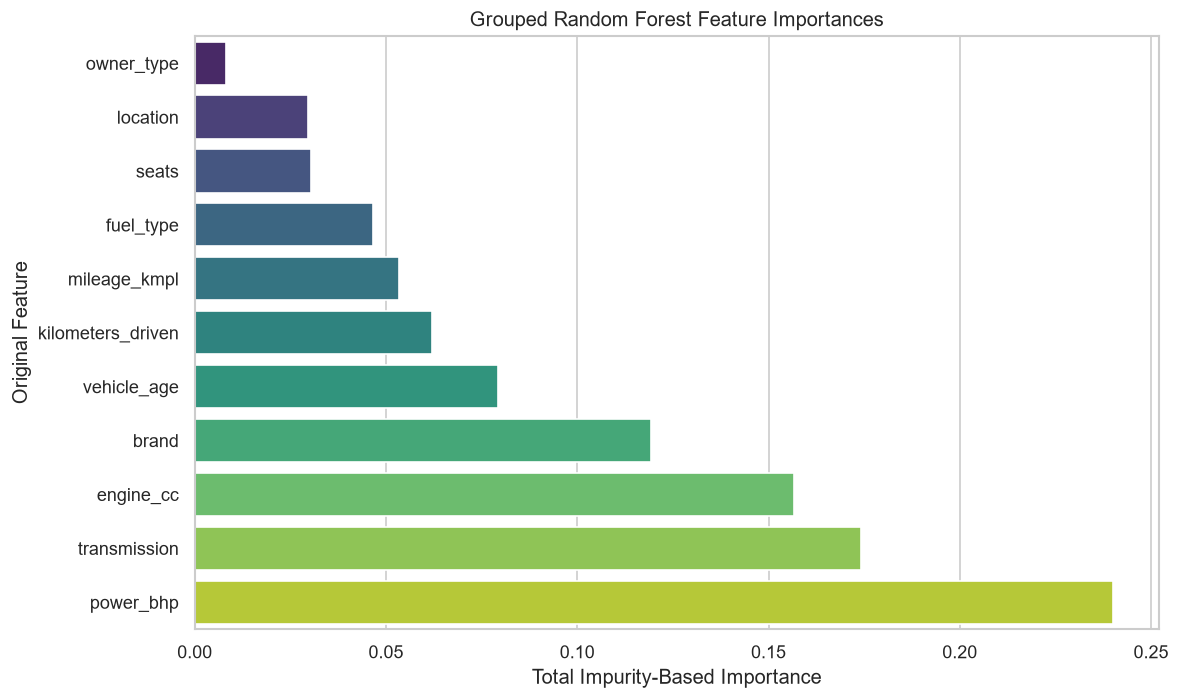

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=grouped_importance.sort_values("importance"),
    x="importance",
    y="feature_group",
    hue="feature_group",
    palette="viridis",
    legend=False,
    ax=ax,
)

ax.set_title("Grouped Random Forest Feature Importances")
ax.set_xlabel("Total Impurity-Based Importance")
ax.set_ylabel("Original Feature")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "grouped_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

In [47]:
from pathlib import Path
import joblib

MODEL_PATH = Path("../outputs/models/random_forest_raw_price.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest_pipeline, MODEL_PATH)

print("Model saved to:", MODEL_PATH.resolve())
print("Model size:", f"{MODEL_PATH.stat().st_size / 1_048_576:.2f} MB")

Model saved to: C:\Users\kenda\Documents\Projects\used-car-price-prediction\outputs\models\random_forest_raw_price.joblib
Model size: 33.71 MB


In [49]:
loaded_model = joblib.load(MODEL_PATH)

reload_predictions = loaded_model.predict(X_test)

print(
    "Predictions match:",
    np.allclose(
        random_forest_predictions,
        reload_predictions,
    )
)

print(
    "Reloaded model MAE:",
    round(mean_absolute_error(y_test, reload_predictions), 3),
    "lakh"
)

Predictions match: True
Reloaded model MAE: 1.784 lakh


In [50]:
sample_predictions = X_test.copy()

sample_predictions["actual_price_lakh"] = y_test
sample_predictions["predicted_price_lakh"] = reload_predictions
sample_predictions["absolute_error_lakh"] = (
    sample_predictions["actual_price_lakh"]
    - sample_predictions["predicted_price_lakh"]
).abs()

display(
    sample_predictions[
        [
            "brand",
            "vehicle_age",
            "kilometers_driven",
            "fuel_type",
            "transmission",
            "actual_price_lakh",
            "predicted_price_lakh",
            "absolute_error_lakh",
        ]
    ]
    .sort_values("absolute_error_lakh")
    .head(10)
)

,brand,vehicle_age,kilometers_driven,fuel_type,transmission,actual_price_lakh,predicted_price_lakh,absolute_error_lakh
5869,Maruti,9,37000.0,Petrol,Manual,2.10,2.100614,0.000614
5663,Renault,4,41000.0,Petrol,Manual,3.25,3.251150,0.001150
5069,Volkswagen,5,58134.0,Petrol,Manual,4.64,4.637901,0.002099
812,Maruti,7,39929.0,Diesel,Manual,6.56,6.557203,0.002797
1786,BMW,10,83000.0,Diesel,Automatic,12.75,12.746058,0.003942
2895,Ford,8,71558.0,Diesel,Manual,3.30,3.305317,0.005317
4589,Honda,10,48689.0,Petrol,Manual,3.87,3.876570,0.006570
1700,Hyundai,9,108242.0,Diesel,Manual,4.25,4.257336,0.007336
4211,Honda,8,63998.0,Petrol,Automatic,5.42,5.427459,0.007459
4296,Volkswagen,2,20000.0,Petrol,Manual,5.50,5.507630,0.007630


In [51]:
import json
import sklearn

metadata = {
    "model_name": "Random Forest Regressor",
    "target": "price",
    "target_unit": "lakh",
    "target_transformation": "none",
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "features": features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "random_state": 42,
    "test_size": 0.20,
    "hyperparameters": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
    },
    "test_metrics": {
        "mae_lakh": round(float(random_forest_results["mae"]), 3),
        "rmse_lakh": round(float(random_forest_results["rmse"]), 3),
        "r2": round(float(random_forest_results["r2"]), 3),
    },
    "libraries": {
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

METADATA_PATH = Path("../outputs/models/random_forest_raw_price_metadata.json")

with open(METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4)

print("Metadata saved to:", METADATA_PATH.resolve())

Metadata saved to: C:\Users\kenda\Documents\Projects\used-car-price-prediction\outputs\models\random_forest_raw_price_metadata.json


In [52]:
print("Expected model input columns:")
print(list(loaded_model.feature_names_in_))

Expected model input columns:
['vehicle_age', 'kilometers_driven', 'mileage_kmpl', 'engine_cc', 'power_bhp', 'seats', 'brand', 'location', 'fuel_type', 'transmission', 'owner_type']


## Using the saved model

The model expects raw, cleaned input columns. The pipeline performs its own preprocessing before generating a price estimate.

import joblib
import pandas as pd

model = joblib.load(
    "outputs/models/random_forest_raw_price.joblib"
)

new_vehicle = pd.DataFrame(
    [
        {
            "vehicle_age": 5,
            "kilometers_driven": 45_000,
            "mileage_kmpl": 18.0,
            "engine_cc": 1497.0,
            "power_bhp": 117.0,
            "seats": 5.0,
            "brand": "Honda",
            "location": "Mumbai",
            "fuel_type": "Petrol",
            "transmission": "Manual",
            "owner_type": "First",
        }
    ]
)

predicted_price_lakh = model.predict(new_vehicle)[0]

print(f"Estimated listing price: {predicted_price_lakh:.2f} lakh")

# Modelling conclusions

- The median baseline produced an MAE of 5.998 lakh, RMSE of 11.696 lakh, and \(R^2\) of −0.112.
- Ridge Regression substantially improved on the baseline, achieving an MAE of 3.118 lakh, RMSE of 5.409 lakh, and \(R^2\) of 0.762.
- The raw-target Random Forest achieved the strongest overall fit, with an MAE of 1.784 lakh, RMSE of 3.917 lakh, and \(R^2\) of 0.875.
- The log-target Random Forest achieved a marginally lower MAE of 1.772 lakh but a higher RMSE of 4.329 lakh and lower \(R^2\) of 0.848 after predictions were transformed back to the original price scale.
- The raw-target Random Forest was selected as the primary model because it had the lowest RMSE and highest \(R^2\), while its MAE was only 0.012 lakh higher than the log-target version.
- Prediction errors were substantially larger for uncommon, high-value luxury listings. Several premium vehicles were underpredicted, and one Porsche listing was predicted at 51.03 lakh against a recorded price of 2.02 lakh; this record appears unusually priced relative to its attributes and may be a data-quality anomaly.
- The most influential individual predictors were power, engine displacement, transmission, vehicle age, kilometres driven, and mileage. Grouped categorical features such as brand and fuel type also contributed.
- Feature importances identify predictive signal in this model; they do not establish that changing a particular vehicle characteristic would cause a particular price change.

## Limitations and future work

- The target is an advertised listing price, not a confirmed transaction price.
- The data covers a specific market and time period, so results may not generalise to current or other regional markets.
- The first-word brand extraction imperfectly represents multi-word manufacturers; for example, `Land Rover` appears as `Land`.
- Model name and trim information were excluded from the initial model because raw vehicle names are high-cardinality fields. Carefully engineered make/model/trim features could improve premium-segment predictions.
- Some technical attributes were missing and were median-imputed during modelling.
- Uncommon premium cars had larger errors, partly because there were fewer comparable training examples.

In [54]:
print(f"{MODEL_PATH.stat().st_size / 1_048_576:.2f} MB")

33.71 MB
